In [1]:
# Instalación de dependencias necesarias para QLoRA y SLMs
!pip install -q -U pip
!pip install -q huggingface_hub transformers peft accelerate bitsandbytes datasets tqdm

In [2]:
!pip install -q -U bitsandbytes>=0.46.1 transformers accelerate peft

In [8]:
# -*- coding: utf-8 -*-
import kagglehub
import pandas as pd
import numpy as np
import os, time, psutil, gc, glob
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, matthews_corrcoef, precision_score, f1_score
from sklearn.preprocessing import RobustScaler
from transformers import AutoModel, AutoConfig, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from tqdm.auto import tqdm  # Barra de progreso

# ==========================================
# 1. CONFIGURACIÓN Y LISTA DE MODELOS
# ==========================================
FEATURES_UNIVERSAL = [
    'HH_jit_L0.1_mean', 'MI_dir_L5_weight', 'H_L5_weight', 'HpHp_L0.01_radius',
    'HpHp_L0.01_std', 'HH_L0.1_radius', 'HH_L0.01_std', 'HH_L0.1_weight',
    'MI_dir_L0.1_mean', 'HH_jit_L5_mean', 'HpHp_L0.1_weight', 'HH_jit_L0.1_weight',
    'HH_L0.01_covariance', 'HpHp_L0.1_radius', 'HpHp_L5_magnitude'
]

slm_benchmark_list = [
    {"name": "DistilRoBERTa", "id": "distilroberta-base"},
    {"name": "Qwen2.5-0.5B", "id": "Qwen/Qwen2.5-0.5B-Instruct"},
    {"name": "Phi-1.5", "id": "microsoft/phi-1_5"},
    {"name": "TinyLlama-1.1B", "id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0"},
    {"name": "SmolLM-360M", "id": "HuggingFaceTB/SmolLM-360M-Instruct"},
    {"name": "Gemma-4-E2B", "id": "google/gemma-4-E2B-it"}
]

# PARÁMETROS DE VELOCIDAD EXTREMA (Ajustables para prueba rápida)
MUESTRAS_BENIGN = 5000
MUESTRAS_ATAQUE = 2000
EPOCHS = 1

# ==========================================
# 2. CARGA DE DATOS ULTRA RÁPIDA
# ==========================================
def preparar_datos_rapidos(path):
    def cargar_eficiente(patron, label, n):
        archivos = glob.glob(os.path.join(path, '**', patron), recursive=True)
        if not archivos: return pd.DataFrame()
        try:
            # Leemos solo N filas, saltando la lógica de contar líneas en disco
            df = pd.read_csv(archivos[0], usecols=FEATURES_UNIVERSAL, nrows=n).dropna()
            df['label'] = label
            return df
        except:
            return pd.DataFrame()

    print("⚡ Cargando datos del dataset N-BaIoT...")
    df_total = pd.concat([
        cargar_eficiente('*.benign.csv', 0, MUESTRAS_BENIGN),
        cargar_eficiente('*.mirai.*.csv', 1, MUESTRAS_ATAQUE),
        cargar_eficiente('*.gafgyt.*.csv', 2, MUESTRAS_ATAQUE)
    ], ignore_index=True)

    labels = df_total.pop('label').values
    scaler = RobustScaler()
    X = scaler.fit_transform(df_total.values)

    X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, stratify=labels, random_state=42)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long()), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long()), batch_size=128, shuffle=False)
    return train_loader, test_loader

# ==========================================
# 3. ARQUITECTURA QLoRA UNIVERSAL (CORREGIDA)
# ==========================================
class SLMEdgeQLoRA(nn.Module):
    def __init__(self, checkpoint, num_features, num_classes=3):
        super().__init__()
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        self.config = AutoConfig.from_pretrained(checkpoint, trust_remote_code=True)
        if self.config.pad_token_id is None:
            self.config.pad_token_id = self.config.eos_token_id if self.config.eos_token_id else 0

        self.transformer = AutoModel.from_pretrained(
            checkpoint, config=self.config, trust_remote_code=True,
            quantization_config=bnb_config, device_map="auto"
        )

        self.hidden_size = getattr(self.config, "hidden_size", getattr(self.config, "d_model", 768))
        self.embed_size = getattr(self.config, "embedding_size", self.hidden_size)

        # DEFINICIÓN DE CAPAS
        self.feature_projector = nn.Linear(1, self.embed_size)
        self.feature_embeddings = nn.Parameter(torch.randn(1, num_features, self.embed_size))
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, num_classes)
        )

    def forward(self, x):
        # DETECTAR DISPOSITIVO Y TIPO DINÁMICAMENTE
        # Esto asegura que todo esté en el mismo lugar (GPU) y formato (float16/32)
        device = next(self.transformer.parameters()).device
        dtype = next(self.transformer.parameters()).dtype

        x = x.unsqueeze(-1).to(device).to(torch.float32) # Entra en float32

        # Proyectar y sumar (asegurando que las capas locales estén en el device correcto)
        tokens = (self.feature_projector.to(device)(x) + self.feature_embeddings.to(device)).to(dtype)

        outputs = self.transformer(inputs_embeds=tokens)
        hidden_states = outputs.last_hidden_state if hasattr(outputs, 'last_hidden_state') else outputs[0]

        pooled = hidden_states.mean(dim=1).to(torch.float32)
        return self.classifier.to(device)(pooled)

# ==========================================
# 4. CAPTURA DE MÉTRICAS
# ==========================================
def capturar_metricas(model, loader, device, nombre_modelo, fase, epoch):
    model.eval()
    y_true, y_pred = [], []
    mem_uso = psutil.Process().memory_info().rss / (1024 * 1024)
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024 * 1024)

    inicio_t = time.perf_counter()
    with torch.no_grad():
        for bx, by in loader:
            outputs = model(bx.to(device))
            y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            y_true.extend(by.numpy())

    tiempo_ms = ((time.perf_counter() - inicio_t) / len(loader.dataset)) * 1000
    return {
        "Modelo": nombre_modelo, "Fase": fase, "Epoch": epoch,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "F1-Macro": round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "RAM_MB": round(mem_uso, 2), "Storage_MB": round(param_size, 2), "Infer_ms": round(tiempo_ms, 4)
    }

# ==========================================
# 5. EJECUCIÓN CON PROGRESO (TQDM)
# ==========================================
path = kagglehub.dataset_download("mkashifn/nbaiot-dataset")
train_loader, test_loader = preparar_datos_rapidos(path)

device = "cuda" if torch.cuda.is_available() else "cpu"
historico_final = []

for slm in slm_benchmark_list:
    try:
        print(f"\n--- Iniciando Evaluación: {slm['name']} ---")
        model = SLMEdgeQLoRA(slm['id'], len(FEATURES_UNIVERSAL))

        # Setup QLoRA
        model.transformer = prepare_model_for_kbit_training(model.transformer)
        peft_config = LoraConfig(r=8, lora_alpha=32, target_modules="all-linear", task_type=TaskType.FEATURE_EXTRACTION)
        model.transformer = get_peft_model(model.transformer, peft_config)

        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        # Entrenamiento con Barra de Progreso
        model.train()
        pbar = tqdm(train_loader, desc=f"Training {slm['name']}", unit="batch")

        for bx, by in pbar:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        # Evaluación
        print(f"🧐 Evaluando métricas para {slm['name']}...")
        res = capturar_metricas(model, test_loader, device, slm['name'], "QLoRA_4bit", 1)
        historico_final.append(res)

        print(f"✅ Resultado {slm['name']} -> F1: {res['F1-Macro']} | RAM: {res['RAM_MB']} MB")

        # Guardado preventivo
        pd.DataFrame(historico_final).to_csv("benchmark_iot_qlora.csv", index=False)

        # Limpieza Crítica de Memoria
        del model, optimizer; gc.collect(); torch.cuda.empty_cache()
        time.sleep(2) # Respiro para el hardware

    except Exception as e:
        print(f"❌ Error crítico en {slm['name']}: {e}")
        gc.collect(); torch.cuda.empty_cache()

print("\n✨ Benchmark finalizado con éxito. Resultados en 'benchmark_iot_qlora.csv'")

Using Colab cache for faster access to the 'nbaiot-dataset' dataset.
⚡ Cargando datos del dataset N-BaIoT...

--- Iniciando Evaluación: DistilRoBERTa ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training DistilRoBERTa:   0%|          | 0/113 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

🧐 Evaluando métricas para TinyLlama-1.1B...
✅ Resultado TinyLlama-1.1B -> F1: 0.9946 | RAM: 2861.58 MB

--- Iniciando Evaluación: SmolLM-360M ---


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Training SmolLM-360M:   0%|          | 0/113 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


🧐 Evaluando métricas para SmolLM-360M...
✅ Resultado SmolLM-360M -> F1: 0.9977 | RAM: 2861.64 MB

--- Iniciando Evaluación: Gemma-4-E2B ---
❌ Error crítico en Gemma-4-E2B: 'Gemma4Config' object has no attribute 'pad_token_id'

✨ Benchmark finalizado con éxito. Resultados en 'benchmark_iot_qlora.csv'



📊 TABLA DE RESULTADOS DEL BENCHMARK


Modelo,Fase,Epoch,Accuracy,Precision,F1-Macro,MCC,RAM_MB,Storage_MB,Infer_ms
Qwen2.5-0.5B,QLoRA_4bit,1,0.998,0.9989,0.9978,0.9964,1742.61,707.07,2.3519
Phi-1.5,QLoRA_4bit,1,0.996,0.9978,0.9955,0.9929,2324.64,1005.25,4.9758
TinyLlama-1.1B,QLoRA_4bit,1,0.995,0.9961,0.9944,0.9911,2889.79,736.59,3.9104
SmolLM-360M,QLoRA_4bit,1,0.994,0.9945,0.9933,0.9893,2863.66,346.88,2.2372
DistilRoBERTa,QLoRA_4bit,1,0.991,0.9874,0.9895,0.9840,1563.05,172.18,0.2801


/tmp/ipykernel_10505/1504525483.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Modelo', y='F1-Macro', palette='viridis')
/tmp/ipykernel_10505/1504525483.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Modelo', y='Infer_ms', palette='magma')


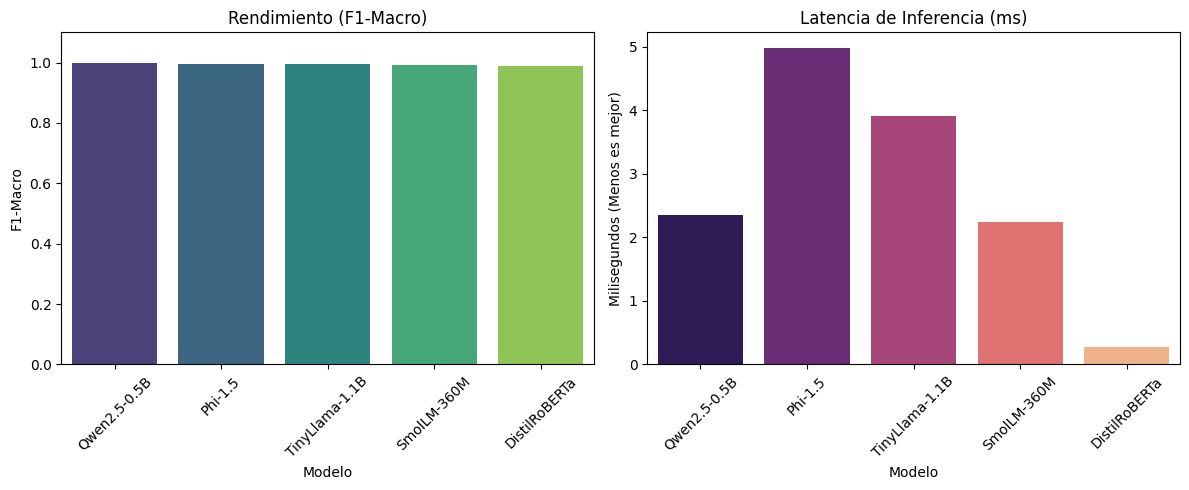

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def mostrar_resultados(csv_path="benchmark_iot_qlora.csv"):
    try:
        # 1. Cargar el archivo
        df = pd.read_csv(csv_path)

        if df.empty:
            print("⚠️ El archivo está vacío. Espera a que termine al menos un modelo.")
            return

        # 2. Ordenar por F1-Macro (el estándar para IoT) de mejor a peor
        df = df.sort_values(by='F1-Macro', ascending=False)

        # 3. Mostrar la tabla con estilo
        print("\n📊 TABLA DE RESULTADOS DEL BENCHMARK")
        display(HTML(df.to_html(classes='table table-striped', index=False)))

        # 4. Gráfica comparativa rápida
        plt.figure(figsize=(12, 5))

        # Subplot 1: Calidad del modelo (F1-Score)
        plt.subplot(1, 2, 1)
        sns.barplot(data=df, x='Modelo', y='F1-Macro', palette='viridis')
        plt.title('Rendimiento (F1-Macro)')
        plt.xticks(rotation=45)
        plt.ylim(0, 1.1)

        # Subplot 2: Eficiencia (Latencia de Inferencia)
        plt.subplot(1, 2, 2)
        sns.barplot(data=df, x='Modelo', y='Infer_ms', palette='magma')
        plt.title('Latencia de Inferencia (ms)')
        plt.ylabel('Milisegundos (Menos es mejor)')
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

        # 5. Guardar un resumen en Excel opcionalmente
        # df.to_excel("resumen_benchmark.xlsx", index=False)

    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo '{csv_path}'.")
        print("Asegúrate de que el código del benchmark haya corrido correctamente.")

# Ejecutar la función
mostrar_resultados()

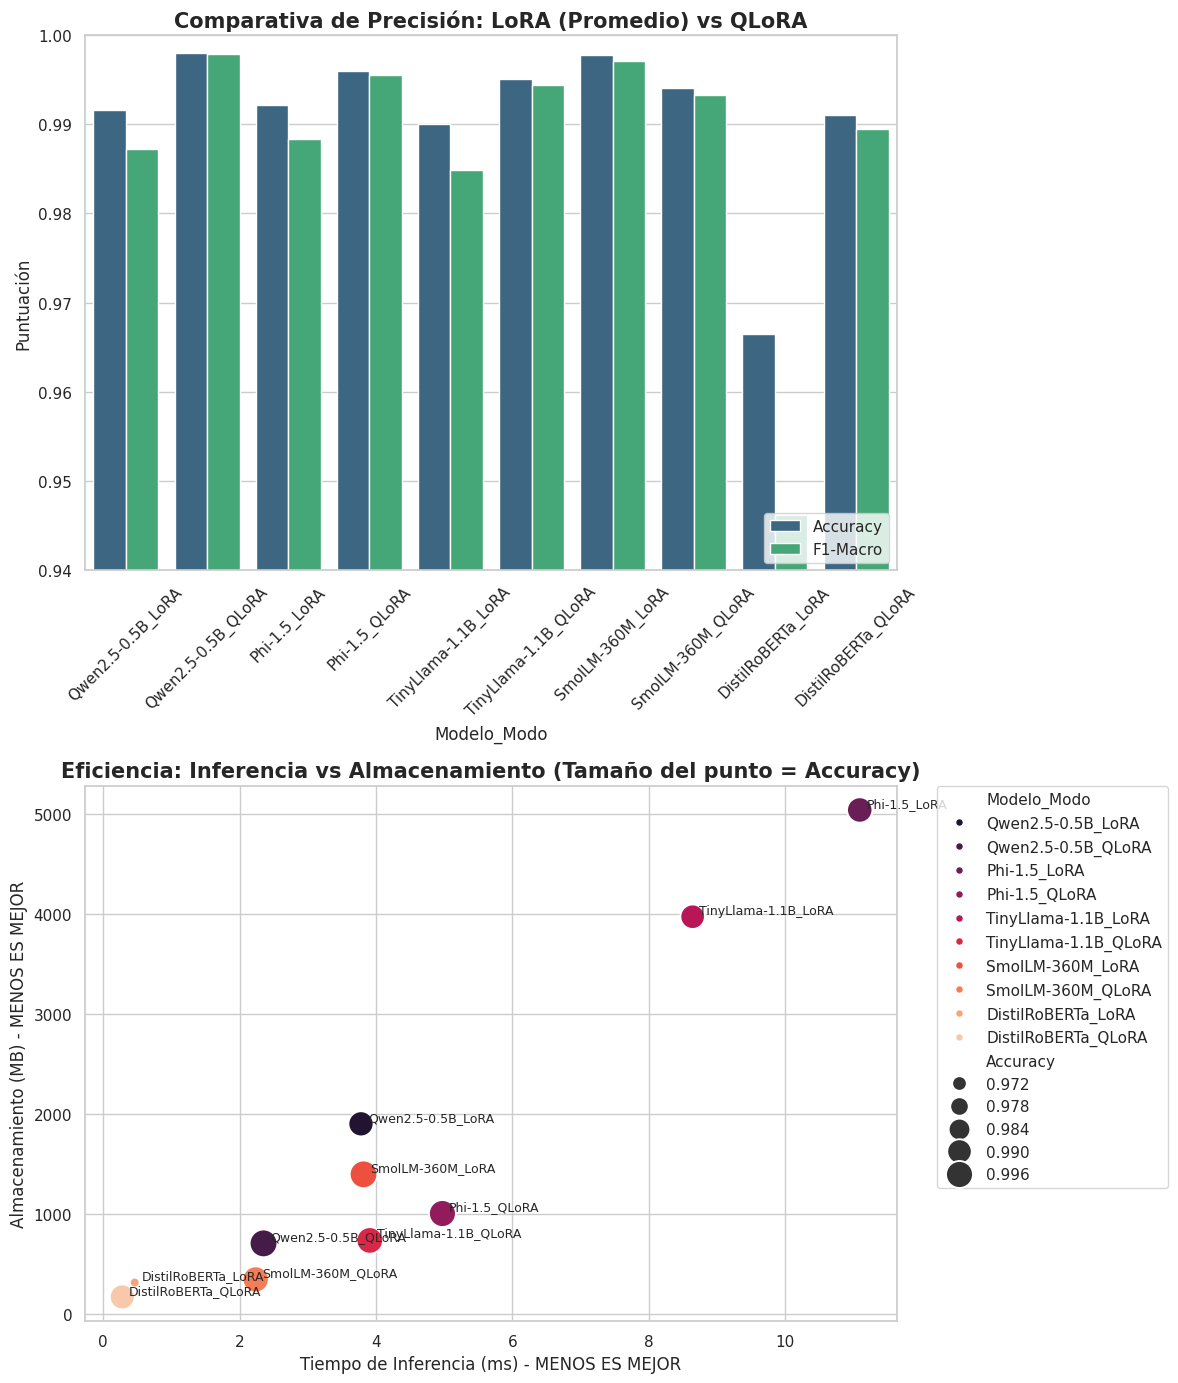

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparar los datos procesados
data = {
    'Modelo_Modo': [
        'Qwen2.5-0.5B_LoRA', 'Qwen2.5-0.5B_QLoRA',
        'Phi-1.5_LoRA', 'Phi-1.5_QLoRA',
        'TinyLlama-1.1B_LoRA', 'TinyLlama-1.1B_QLoRA',
        'SmolLM-360M_LoRA', 'SmolLM-360M_QLoRA',
        'DistilRoBERTa_LoRA', 'DistilRoBERTa_QLoRA'
    ],
    'Accuracy': [
        0.9916, 0.9980,  # Qwen
        0.9921, 0.9960,  # Phi
        0.9900, 0.9950,  # TinyLlama
        0.9977, 0.9940,  # SmolLM
        0.9665, 0.9910   # DistilRoBERTa
    ],
    'F1-Macro': [
        0.9872, 0.9978,  # Qwen
        0.9883, 0.9955,  # Phi
        0.9849, 0.9944,  # TinyLlama
        0.9971, 0.9933,  # SmolLM
        0.9462, 0.9895   # DistilRoBERTa
    ],
    'Inferencia (ms)': [
        3.7813, 2.3519,  # Qwen
        11.0964, 4.9758, # Phi
        8.6454, 3.9104,  # TinyLlama
        3.8187, 2.2372,  # SmolLM
        0.4630, 0.2801   # DistilRoBERTa
    ],
    'Storage (MB)': [
        1901.44, 707.07, # Qwen
        5037.25, 1005.25,# Phi
        3970.59, 736.59, # TinyLlama
        1396.88, 346.88, # SmolLM
        315.90, 172.18   # DistilRoBERTa
    ]
}

df = pd.DataFrame(data)

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# --- GRÁFICO 1: ACCURACY Y F1-MACRO ---
df_melted = df.melt(id_vars='Modelo_Modo', value_vars=['Accuracy', 'F1-Macro'],
                    var_name='Métrica', value_name='Valor')

sns.barplot(data=df_melted, x='Modelo_Modo', y='Valor', hue='Métrica', ax=axes[0], palette='viridis')
axes[0].set_title('Comparativa de Precisión: LoRA (Promedio) vs QLoRA', fontsize=15, fontweight='bold')
axes[0].set_ylim(0.94, 1.0)
axes[0].set_ylabel('Puntuación')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower right')

# --- GRÁFICO 2: VELOCIDAD VS ALMACENAMIENTO (Tamaño = Accuracy) ---
# Se cambia 'size' a 'Accuracy' y se ajustan los 'sizes' para notar la diferencia en valores altos
sns.scatterplot(data=df, x='Inferencia (ms)', y='Storage (MB)', hue='Modelo_Modo',
                size='Accuracy', sizes=(50, 400), ax=axes[1], palette='rocket')

# Añadir etiquetas a los puntos
for i in range(df.shape[0]):
    axes[1].text(df['Inferencia (ms)'][i] + 0.1, df['Storage (MB)'][i],
                 df['Modelo_Modo'][i], fontsize=9, verticalalignment='bottom')

axes[1].set_title('Eficiencia: Inferencia vs Almacenamiento (Tamaño del punto = Accuracy)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Tiempo de Inferencia (ms) - MENOS ES MEJOR')
axes[1].set_ylabel('Almacenamiento (MB) - MENOS ES MEJOR')

# Ajustar leyenda para que no tape los puntos
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()